Please refer to [Neural Tangents](https://github.com/google/neural-tangents) for dependencies.  
You may need [JAX with GPU Support](https://jax.readthedocs.io/en/latest/installation.html#install-nvidia-gpu).

In [1]:
from jax import random
from neural_tangents import stax
import jax.numpy as jnp
import neural_tangents as nt

from matplotlib import pyplot as plt

import dataloaders

2024-10-02 07:31:24.198842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-02 07:31:24.216996: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-02 07:31:24.222562: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-02 07:31:25.068461: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import importlib
importlib.reload(dataloaders)

<module 'dataloaders' from '/home/zhang/RP_ML/Active-learning-features/refactored-aaai25/dataloaders/__init__.py'>

In [3]:
#########################################
# Network definition

hidden_dim = 2048
in_dim = 1

init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(1)
)

key = random.PRNGKey(1)
# x = random.normal(key, (10, 1))

#########################################
# Data generation

ntx = dataloaders.get_train_X(N = 5)
nvx = dataloaders.get_val_X(N = 256)

x_tr = jnp.array(ntx)[:, None]
x_va = jnp.array(nvx)[:, None]
y_tr = jnp.array(dataloaders.get_Y(ntx, 0.03))[:, None]
y_va = jnp.array(dataloaders.get_Y(nvx))[:, None]

_, params = init_fn(key, input_shape=x_tr.shape)

2024-10-02 07:31:27.833684: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.6.20). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
################### Direct computation of Linearized dynamics on MSE #####################

predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, x_tr, y_tr, diag_reg = 1e-3)
# y_val_nngp = predict_fn(x_test = x_va, get = 'nngp')

y_val_ntk, y_val_ntk_cov = predict_fn(x_test = x_va, get = 'ntk', compute_cov = True)
# y_val_ntk = predict_fn(x_test = x_va, get = 'nngp', compute_cov = True)

y = apply_fn(params, x_va)
y_var = kernel_fn(x_va, x_va, 'nngp')

# print(x_va)
# print(y_val_ntk)

ntk_mean = jnp.reshape(y_val_ntk, (-1,))
ntk_std = jnp.sqrt(jnp.diag(y_val_ntk_cov))

cov_scale = 2
y_lower = ntk_mean - ntk_std * cov_scale
y_upper = ntk_mean + ntk_std * cov_scale

In [5]:
##################### Upper bound by Gronwall Inequality ######################

Ozz = jnp.diag(kernel_fn(x_va, x_va, 'ntk'))
Oxx = jnp.diag(kernel_fn(x_tr, x_tr, 'ntk'))
Ozx = kernel_fn(x_va, x_tr, 'ntk')

addition_term = jnp.min(Oxx[None, :] - 2 * Ozx, axis = 1)
UB = Ozz + addition_term

# UB = 0.2 * jnp.exp(2 * jnp.sqrt(UB) - 1)
UB = 0.6 * jnp.sqrt(UB)

mean_term = jnp.mean(Oxx[None, :] - 2 * Ozx, axis = 1)
UB_mean = Ozz + mean_term

<Figure size 210x150 with 0 Axes>

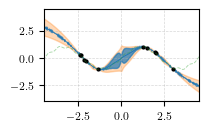

In [8]:
############################### VISUALIZATION #################################
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()
# plt.figure(figsize = (3.5, 1.5))

fig, ax = plt.subplots(figsize = (2.0, 1.2))

plt.xlim(-4.5, 4.5)

plt.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)

# plt.fill_between(x_va[:, 0], ntk_mean - Ozz, ntk_mean + Ozz, alpha = 0.04, color = 'C3', label = "O(z,z)")
# plt.fill_between(x_va[:, 0], ntk_mean - UB_mean, ntk_mean + UB_mean, alpha = 0.14, color = 'C0', label = "Upper bound (mean)")
plt.fill_between(x_va[:, 0], ntk_mean - UB, ntk_mean + UB, alpha = 0.3, color = 'C1', label = "Upper bound")
plt.fill_between(x_va[:, 0], y_lower, y_upper, alpha = 0.7, color = 'C0', label = "Exact trained ensemble")

plt.plot(x_va[:, 0], ntk_mean, linewidth=0.65, label = "trained")
plt.plot(x_tr[:, 0], y_tr[:, 0], 'o', markersize=2, color='k', label = "dataset")
plt.plot(x_va[:, 0], y_va[:, 0], '--', linewidth=0.65, alpha = 0.4, color='C2', label = "target")

# ax.text(.1,.88,'\\textbf{a)}',
#         horizontalalignment='center',
#         transform=ax.transAxes)

# plt.legend()
# plt.savefig("test.png", dpi=300)
plt.savefig("toy-regression.pdf", format="pdf", bbox_inches = 'tight')
# plt.show()

In [16]:
# # Lambda sweep
# power_1_0_near = "77.47529393	77.47529393	77.47529393	77.63842506	77.63842506	77.63842506	77.75320262	77.75320262	77.75320262	77.67055482	77.67055482	77.67055482	77.63633973	77.63633973	77.63633973	77.59811483	77.59811483	77.59811483	77.55398945	77.55398945	77.55398945	77.50593655	77.50593655	77.50593655	77.46493986	77.46493986	77.46493986	77.3787585	77.3787585	77.3787585	77.33361273	77.33361273	77.33361273	77.28729174	77.28729174	77.28729174"
# power_1_0_far = "88.00966194	88.00966194	88.00966194	87.98059449	87.98059449	87.98059449	87.89553644	87.89553644	87.89553644	87.96559213	87.96559213	87.96559213	88.00972212	88.00972212	88.00972212	88.04199084	88.04199084	88.04199084	88.06353545	88.06353545	88.06353545	88.07494993	88.07494993	88.07494993	88.07784419	88.07784419	88.07784419	88.07093809	88.07093809	88.07093809	88.0625184	88.0625184	88.0625184	88.05132062	88.05132062	88.05132062"
# power_1_0_near = [float(f) for f in power_1_0_near.split('\t')[::3]]
# power_1_0_far = [float(f) for f in power_1_0_far.split('\t')[::3]]

# power_1_5_near = "77.48533632	77.48533632	77.48533632	77.74550535	77.74550535	77.74550535	78.06231872	78.06231872	78.06231872	77.76234093	77.76234093	77.76234093	77.60364827	77.60364827	77.60364827	77.42665428	77.42665428	77.42665428	77.23168573	77.23168573	77.23168573	77.02090198	77.02090198	77.02090198	76.84605992	76.84605992	76.84605992	76.49244304	76.49244304	76.49244304	76.31502782	76.31502782	76.31502782	76.13818158	76.13818158	76.13818158"
# power_1_5_far = "88.01193599	88.01193599	88.01193599	87.98770487	87.98770487	87.98770487	87.75456287	87.75456287	87.75456287	87.48451388	87.48451388	87.48451388	87.47194148	87.47194148	87.47194148	87.43102459	87.43102459	87.43102459	87.35335406	87.35335406	87.35335406	87.23985383	87.23985383	87.23985383	87.12899159	87.12899159	87.12899159	86.87736809	86.87736809	86.87736809	86.741379	86.741379	86.741379	86.60101111	86.60101111	86.60101111"
# power_1_5_near = [float(f) for f in power_1_5_near.split('\t')[::3]]
# power_1_5_far = [float(f) for f in power_1_5_far.split('\t')[::3]]

# lambds = [5.0, 4.0, 3, 2, 1.75, 1.5, 1.25, 1.0, 0.8, 0.4, 0.2, 0.0]

In [17]:
# # power sweep
# lambd_0_near = "69.86849886	69.75694594	69.98005179	71.87362332	71.77764036	71.96960628	73.60855593	73.53119272	73.68591914	75.03002224	74.97214114	75.08790334	76.09517298	76.05216438	76.13818158	76.8319115	76.81443152	76.84939148	77.27705332	77.2668149	77.28729174	77.47915541	77.46952481	77.488786	77.49489648	77.48715925	77.50263371	77.47028247	77.46251408	77.47805086	77.43961426	77.43284587	77.44638266	77.41083404	77.40443799	77.41723009	77.389645	77.38460556	77.39468443"
# lambd_0_far = "74.67519357	74.56766209	74.78272504	79.42725829	79.32485478	79.5296618	82.80645997	82.73834084	82.87457911	85.10399016	85.06921631	85.13876402	86.60481622	86.60101111	86.60862133	87.54242346	87.54174298	87.54310394	88.05590152	88.05132062	88.06048243	88.2547272	88.24368059	88.2657738	88.23357717	88.22074492	88.24640941	88.18588379	88.17658657	88.19518102	88.12859843	88.12133293	88.13586394	88.06940985	88.06544934	88.07337036	88.0240459	88.02302941	88.02506239"
# lambd_0_near = [float(f) for f in lambd_0_near.split('\t')[::3]]
# lambd_0_far = [float(f) for f in lambd_0_far.split('\t')[::3]]

# lambd_1_near = "73.62809892	73.598536	73.65766183	74.79978739	74.74886581	74.85070897	75.75734097	75.71394223	75.8007397	76.486678	76.45115208	76.52220392	76.99973429	76.9785666	77.02090198	77.32928913	77.32626017	77.33231809	77.50340718	77.50087782	77.50593655	77.54540198	77.54084689	77.54995707	77.49616465	77.49115349	77.5011758	77.4646232	77.45899211	77.47025428	77.43281017	77.42746508	77.43815526	77.40641632	77.40079766	77.41203499	77.38842096	77.38408871	77.39275321"
# lambd_1_far = "80.46538301	80.35405209	80.57671393	83.19493572	83.12053419	83.26933726	85.10276076	85.05569322	85.1498283	86.39334574	86.36790951	86.41878197	87.25176107	87.23985383	87.2636683	87.79266666	87.78318034	87.80215298	88.08686857	88.07494993	88.09878722	88.19463504	88.17976284	88.20950724	88.16926282	88.15656115	88.18196448	88.13524895	88.12597275	88.14452515	88.09409519	88.08688713	88.10130325	88.05152158	88.04778963	88.05525352	88.01930399	88.01830996	88.02029803"
# lambd_1_near = [float(f) for f in lambd_1_near.split('\t')[::3]]
# lambd_1_far = [float(f) for f in lambd_1_far.split('\t')[::3]]

# powers = [2.5, 2.25, 2.0, 1.75, 1.5, 1.25, 1.0, 0.75, 0.5, 0.4, 0.3, 0.2, 0.1]

In [38]:
import pandas as pd

lambd_0 = pd.read_csv("sweep_results/sweep_IN200_lambd_0.0.csv")
lambd_1_5 = pd.read_csv("sweep_results/sweep_IN200_lambd_1.5.csv")

power_0_5 = pd.read_csv("sweep_results/sweep_IN200_power_0.5.csv")
power_1_5 = pd.read_csv("sweep_results/sweep_IN200_power_1.5.csv")
power_2_0 = pd.read_csv("sweep_results/sweep_IN200_power_2.0.csv")

lambd_0 = lambd_0[lambd_0['perturb_power'] < 2.0].dropna()
lambd_1_5 = lambd_1_5[lambd_1_5['perturb_power'] < 2.0].dropna()

power_0_5 = power_0_5.dropna()
power_1_5 = power_1_5.dropna()
power_2_0 = power_2_0.dropna()

print(lambd_0)

                 Name    nearood     farood  delta  lambd  perturb_power
6    ancient-sweep-20  81.337859  86.237839    8.0    0.0            1.9
7      happy-sweep-19  81.841382  87.178992    8.0    0.0            1.8
8    stellar-sweep-18  82.260178  87.970867    8.0    0.0            1.7
9      laced-sweep-17  82.616820  88.639327    8.0    0.0            1.6
10     lucky-sweep-16  82.916500  89.202129    8.0    0.0            1.5
11     solar-sweep-15  83.170153  89.671520    8.0    0.0            1.4
12     sandy-sweep-14  83.380435  90.059367    8.0    0.0            1.3
13     lilac-sweep-13  83.550867  90.371555    8.0    0.0            1.2
14      rose-sweep-12  83.682792  90.616118    8.0    0.0            1.1
15   skilled-sweep-11  83.781900  90.805187    8.0    0.0            1.0
16  youthful-sweep-10  83.849013  90.944313    8.0    0.0            0.9
17      major-sweep-9  83.891626  91.041975    8.0    0.0            0.8
18      fiery-sweep-8  83.912969  91.104575    8.0 

<Figure size 210x150 with 0 Axes>

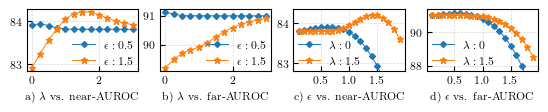

In [43]:
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()

TICK_PADDING = -10

# fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (3.6, 2.5))
fig, ((ax1, ax2, ax3, ax4)) = plt.subplots(1, 4, figsize = (6.6, 0.8))
fig.subplots_adjust(hspace=0.6)

# ax1.plot(lambds, power_1_0_near, '-D', markersize = 3, linewidth = 0.7, label = '$\\epsilon:1$')
# ax1.plot(lambds, power_1_5_near, '-*', markersize = 5, linewidth = 0.7, label = '$\\epsilon:1.5$')
ax1.plot(power_0_5['lambd'], power_0_5['nearood'], '-D', markersize = 3, linewidth = 0.7, label = '$\\epsilon:0.5$')
ax1.plot(power_1_5['lambd'], power_1_5['nearood'], '-*', markersize = 5, linewidth = 0.7, label = '$\\epsilon:1.5$')

ax1.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)
ax1.legend(framealpha=0.0, borderaxespad=0.02)
ax1.set_xlabel("a) $\\lambda$ vs. near-AUROC")
ax1.tick_params(direction="in")

# ax2.plot(lambds, power_1_0_far, '-D', markersize = 3, linewidth = 0.7, label = '$\\epsilon:1$')
# ax2.plot(lambds, power_1_5_far, '-*', markersize = 5, linewidth = 0.7, label = '$\\epsilon:1.5$')
ax2.plot(power_0_5['lambd'], power_0_5['farood'], '-D', markersize = 3, linewidth = 0.7, label = '$\\epsilon:0.5$')
ax2.plot(power_1_5['lambd'], power_1_5['farood'], '-*', markersize = 5, linewidth = 0.7, label = '$\\epsilon:1.5$')

ax2.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)
ax2.legend(framealpha=0.0, borderaxespad=0.02)
ax2.tick_params(direction="in")
ax2.set_xlabel("b) $\\lambda$ vs. far-AUROC")

# ax3.plot(powers, lambd_0_near, '-D', markersize = 3, linewidth = 0.7, label = '$\\lambda:0$')
# ax3.plot(powers, lambd_1_near, '-*', markersize = 5, linewidth = 0.7, label = '$\\lambda:1$')
# ax3.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)

ax3.plot(lambd_0['perturb_power'], lambd_0['nearood'], '-D', markersize = 3, linewidth = 0.7, label = '$\\lambda:0$')
ax3.plot(lambd_1_5['perturb_power'], lambd_1_5['nearood'], '-*', markersize = 5, linewidth = 0.7, label = '$\\lambda:1.5$')
ax3.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)
ax3yl = ax3.get_ylim()
ax3.set_ylim(82.8,ax3yl[1])

ax3.legend(framealpha=0.0, borderaxespad=0.02)
ax3.tick_params(direction="in")
ax3.set_xlabel("c) $\\epsilon$ vs. near-AUROC")


# ax4.plot(powers, lambd_0_far, '-D', markersize = 3, linewidth = 0.7, label = '$\\lambda:0$')
# ax4.plot(powers, lambd_1_far, '-*', markersize = 5, linewidth = 0.7, label = '$\\lambda:1$')
# ax4.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)

ax4.plot(lambd_0['perturb_power'], lambd_0['farood'], '-D', markersize = 3, linewidth = 0.7, label = '$\\lambda:0$')
ax4.plot(lambd_1_5['perturb_power'], lambd_1_5['farood'], '-*', markersize = 5, linewidth = 0.7, label = '$\\lambda:1.5$')
ax4.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)
ax4yl = ax4.get_ylim()
ax4.set_ylim(87.7,ax4yl[1])

ax4.legend(framealpha=0.0, borderaxespad=0.02)
ax4.tick_params(direction="in")
ax4.set_xlabel("d) $\\epsilon$ vs. far-AUROC")

plt.savefig("ablation.pdf", format="pdf", bbox_inches = 'tight')

/tmp/ipykernel_3433071/2346874109.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(['MbNet', 'VGG', 'RegNet'])
/tmp/ipykernel_3433071/2346874109.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(['MbNet', 'VGG', 'RegNet'])


<Figure size 210x150 with 0 Axes>

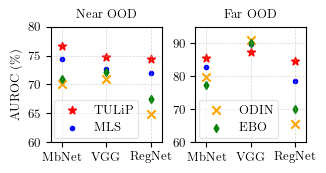

In [83]:
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()

#           Mobile		VGG16		    RegNet Y 16GF	
# 	    Near	Far	    Near	Far	    Near	Far
# TULiP	76.59	85.63	74.82	87.38	74.40	84.55
# MLS	74.39	82.67	72.75	89.78	72.07	78.45
# ODIN	70.09	79.63	70.86	90.83	64.93	65.41
# EBO	71.00	77.46	72.16	89.92	67.50	69.98

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize = (3.3, 1.5))
fig.subplots_adjust(wspace=0.3)

ax1.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)
ax1.scatter([0, 1, 2], [76.59, 74.82, 74.40], marker = '*', c = 'r', label = 'TULiP')
ax1.scatter([0, 1, 2], [74.39, 72.75, 72.07], marker = '.', c = 'b', label = 'MLS')
ax1.scatter([0, 1, 2], [70.09, 70.86, 64.93], marker = 'x', c = 'orange')#, label = 'ODIN')
ax1.scatter([0, 1, 2], [71.00, 72.16, 67.50], marker = 'd', s = 16, c = 'g')#, label = 'EBO')
ax1.set_xticklabels(['MbNet', 'VGG', 'RegNet'])
ax1.set_title("Near OOD")
ax1.legend(framealpha=0.5, borderaxespad=0.3)
ax1.set_xticks([0,1,2])
ax1.set_xlim(-0.25, 2.25)
ax1.set_ylabel("AUROC (\\%)")
ax1.set_ylim(60, 80)

ax2.grid(linestyle = '--', linewidth = 0.5, alpha = 0.5)
ax2.scatter([0, 1, 2], [85.63, 87.38, 84.55], marker = '*', c = 'r')#, label = 'TULiP')
ax2.scatter([0, 1, 2], [82.67, 89.78, 78.45], marker = '.', c = 'b')#, label = 'MLS')
ax2.scatter([0, 1, 2], [79.63, 90.83, 65.41], marker = 'x', c = 'orange', label = 'ODIN')
ax2.scatter([0, 1, 2], [77.46, 89.92, 69.98], marker = 'd', s = 16, c = 'g', label = 'EBO')
ax2.legend(framealpha=0.5, borderaxespad=0.3)
ax2.set_xticklabels(['MbNet', 'VGG', 'RegNet'])
ax2.set_title("Far OOD")
ax2.set_xticks([0,1,2])
ax2.set_xlim(-0.25, 2.25)
ax2.set_ylim(60, 95)

plt.savefig("fig3.pdf", format="pdf", bbox_inches = 'tight')